# Part 3: Linear Models

This notebook compares **Ridge (L2)** and **Lasso (L1)** logistic regression models across different feature sets to find the best linear classifier for the neural activity data.

## Overview
1. **Data Loading** - Load processed features and verify alignment
2. **Data Preparation** - Prepare three feature configurations for comparison
3. **Model Comparison** - Compare Ridge vs Lasso across feature sets with cross-validation
4. **Evaluation** - Analyze results with confusion matrix and per-class metrics
5. **Submission** - Generate final predictions with the best model

In [1]:
# Imports
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import joblib
import time

# Paths
ROOT = Path.cwd().parents[0]
DATA = ROOT / "data"
PROCESSED = DATA / "processed"
PREDICTION = DATA / "prediction"
PREDICTION.mkdir(exist_ok=True)

print("Libraries loaded successfully")

Libraries loaded successfully


## 1. Data Loading and Verification

In [2]:
# Load processed data (from preprocessing notebook)
x_train_processed = pd.read_csv(PROCESSED / "x_train_scaled.csv")
x_test_processed = pd.read_csv(PROCESSED / "x_test_scaled.csv")
y_train = pd.read_csv(PROCESSED / "y_train.csv").iloc[:, 0]

# Load raw data for minimal preprocessing comparison
train_raw = pd.read_csv(DATA / "train.csv")
test_raw = pd.read_csv(DATA / "test.csv")

# Clean up columns
x_train_processed = x_train_processed.loc[:, ~x_train_processed.columns.str.match(r"Unnamed")]
x_test_processed = x_test_processed.loc[:, ~x_test_processed.columns.str.match(r"Unnamed")]
x_test_processed = x_test_processed[x_train_processed.columns]

print(f"Processed features: {x_train_processed.shape}")
print(f"Raw features: {train_raw.shape}")
print(f"Samples: {len(y_train)}")

# Verify alignment
alignment_ok = (y_train.values == train_raw['TRIAL_TYPE'].values).all()
print(f"\n{'✓ Label alignment verified' if alignment_ok else '✗ ALIGNMENT ERROR!'}")

# Check for scaling issues
max_val = x_train_processed.abs().max().max()
print(f"Max absolute value: {max_val:.2f} {'✓' if max_val < 100 else '⚠ Re-run preprocessing!'}")

Processed features: (4407, 2116)
Raw features: (4407, 1383)
Samples: 4407

✓ Label alignment verified
Max absolute value: 40.00 ✓


=== CLASS DISTRIBUTION ===
TRIAL_TYPE
GO W+ lick           711
GO W+ nolick         169
GO W- lick            69
GO W- nolick         813
NOGO W+ lick          88
NOGO W+ nolick       793
NOGO W- lick           3
NOGO W- nolick       880
no tone W+ lick      150
no tone W+ nolick    731
Name: count, dtype: int64

Imbalance ratio: 880/3 = 293x


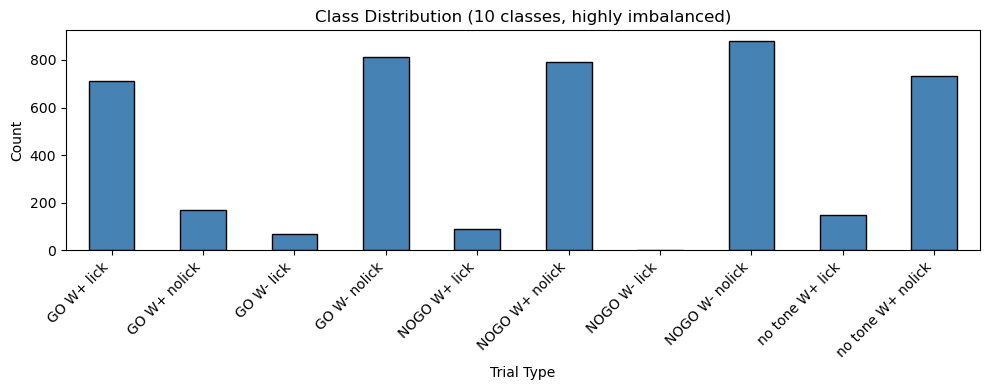

In [3]:
# Class distribution analysis
class_counts = y_train.value_counts().sort_index()
print("=== CLASS DISTRIBUTION ===")
print(class_counts)
print(f"\nImbalance ratio: {class_counts.max()}/{class_counts.min()} = {class_counts.max()/class_counts.min():.0f}x")

plt.figure(figsize=(10, 4))
class_counts.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Class Distribution (10 classes, highly imbalanced)')
plt.xlabel('Trial Type')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 2. Data Preparation

We compare models on three different feature configurations:
1. **All features** - Full processed dataset (PCA + aggregates + session features)
2. **PCA only** - Just PCA components (most generalizable)
3. **Minimal (raw)** - Raw neural features with StandardScaler only (baseline)

In [4]:
# Prepare three feature configurations

# 1. All processed features
X_all_train = x_train_processed.values
X_all_test = x_test_processed.values
y_all = y_train.values

# 2. PCA only (from processed data)
pca_cols = [c for c in x_train_processed.columns if c.startswith('PCA_')]
X_pca_train = x_train_processed[pca_cols].values
X_pca_test = x_test_processed[pca_cols].values

# 3. Minimal: raw neural features + StandardScaler
neural_cols = [c for c in train_raw.columns if c not in ['session_id', 'trial_number', 'TRIAL_TYPE']]
X_raw = train_raw[neural_cols].copy()
X_raw_test = test_raw[neural_cols].copy()
y_raw = train_raw['TRIAL_TYPE'].values

# Apply simple preprocessing
imputer = SimpleImputer(strategy='median')
X_raw_imp = imputer.fit_transform(X_raw)
X_raw_test_imp = imputer.transform(X_raw_test)

scaler = StandardScaler()
X_minimal_train = scaler.fit_transform(X_raw_imp)
X_minimal_test = scaler.transform(X_raw_test_imp)

# Summary
print("=== FEATURE CONFIGURATIONS ===")
print(f"1. All features:    {X_all_train.shape[1]:4d} features (processed)")
print(f"2. PCA only:        {X_pca_train.shape[1]:4d} features (generalizable)")
print(f"3. Minimal (raw):   {X_minimal_train.shape[1]:4d} features (baseline)")

# Store in dictionary for easy iteration
data_configs = {
    "All features": (X_all_train, X_all_test, y_all),
    "PCA only": (X_pca_train, X_pca_test, y_all),
    "Minimal (raw)": (X_minimal_train, X_minimal_test, y_raw),
}

=== FEATURE CONFIGURATIONS ===
1. All features:    2116 features (processed)
2. PCA only:         804 features (generalizable)
3. Minimal (raw):   1350 features (baseline)


c:\Users\milor\anaconda3\envs\MLCourse\lib\site-packages\sklearn\impute\_base.py:653: UserWarning: Skipping features without any observed values: ['wS2_L1_INH_time_0' 'wS2_L1_INH_time_1' 'wS2_L1_INH_time_2'
 'wS2_L1_INH_time_3' 'wS2_L1_INH_time_4' 'wS2_L1_INH_time_5'
 'wS2_L1_INH_time_6' 'wS2_L1_INH_time_7' 'wS2_L1_INH_time_8'
 'wS2_L1_INH_time_9' 'wS2_L1_INH_time_10' 'wS2_L1_INH_time_11'
 'wS2_L1_INH_time_12' 'wS2_L1_INH_time_13' 'wS2_L1_INH_time_14'
 'wS2_L1_INH_time_15' 'wS2_L1_INH_time_16' 'wS2_L1_INH_time_17'
 'wS2_L1_INH_time_18' 'wS2_L1_INH_time_19' 'wS2_L1_INH_time_20'
 'wS2_L1_INH_time_21' 'wS2_L1_INH_time_22' 'wS2_L1_INH_time_23'
 'wS2_L1_INH_time_24' 'wS2_L1_INH_time_25' 'wS2_L1_INH_time_26'
 'wS2_L1_INH_time_27' 'wS2_L1_INH_time_28' 'wS2_L1_INH_time_29']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
c:\Users\milor\anaconda3\envs\MLCourse\lib\site-packages\sklearn\impute\_base.py:653: UserWarning: Skipping features without 

## 3. Model Comparison: Ridge vs Lasso

We compare two regularization strategies:
- **Ridge (L2)**: Shrinks all coefficients toward zero, keeps all features
- **Lasso (L1)**: Promotes sparsity, sets some coefficients exactly to zero

Both use `class_weight='balanced'` to handle class imbalance.

In [ ]:
# Cross-validation comparison of Ridge and Lasso
# Runtime: ~3 minutes

C_values = [0.01, 0.1, 1.0]
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = []

print("Running 5-fold cross-validation...\n")

for data_name, (X_tr, X_te, y) in data_configs.items():
    print(f"=== {data_name} ===")
    
    for C in C_values:
        # Ridge (L2) with lbfgs solver
        ridge = LogisticRegression(
            penalty='l2', solver='lbfgs', C=C, max_iter=1000,
            class_weight='balanced', n_jobs=-1
        )
        ridge_scores = cross_val_score(ridge, X_tr, y, cv=cv, scoring='f1_macro', n_jobs=-1)
        results.append({
            'Data': data_name, 'Model': 'Ridge (L2)', 'C': C,
            'CV F1': ridge_scores.mean(), 'Std': ridge_scores.std()
        })
        
        # Lasso (L1) with liblinear solver (fast)
        lasso = LogisticRegression(
            penalty='l1', solver='liblinear', C=C, max_iter=1000,
            class_weight='balanced'
        )
        lasso_scores = cross_val_score(lasso, X_tr, y, cv=cv, scoring='f1_macro', n_jobs=-1)
        results.append({
            'Data': data_name, 'Model': 'Lasso (L1)', 'C': C,
            'CV F1': lasso_scores.mean(), 'Std': lasso_scores.std()
        })
        
        print(f"  C={C}: Ridge={ridge_scores.mean():.4f}, Lasso={lasso_scores.mean():.4f}")

# Create results DataFrame
results_df = pd.DataFrame(results).sort_values('CV F1', ascending=False)
print("\n" + "="*60)
print("CROSS-VALIDATION RESULTS (sorted by F1)")
print("="*60)
print(results_df.to_string(index=False))

Running 5-fold cross-validation...

=== All features ===


c:\Users\milor\anaconda3\envs\MLCourse\lib\site-packages\sklearn\model_selection\_split.py:811: UserWarning: The least populated class in y has only 3 members, which is less than n_splits=5.
  warnings.warn(
c:\Users\milor\anaconda3\envs\MLCourse\lib\site-packages\sklearn\model_selection\_split.py:811: UserWarning: The least populated class in y has only 3 members, which is less than n_splits=5.
  warnings.warn(


  C=0.01: Ridge=0.4918, Lasso=0.3676


c:\Users\milor\anaconda3\envs\MLCourse\lib\site-packages\sklearn\model_selection\_split.py:811: UserWarning: The least populated class in y has only 3 members, which is less than n_splits=5.
  warnings.warn(
c:\Users\milor\anaconda3\envs\MLCourse\lib\site-packages\sklearn\model_selection\_split.py:811: UserWarning: The least populated class in y has only 3 members, which is less than n_splits=5.
  warnings.warn(


  C=0.1: Ridge=0.4758, Lasso=0.4829


...

  C=0.01: Ridge=0.5086, Lasso=0.3307


c:\Users\milor\anaconda3\envs\MLCourse\lib\site-packages\sklearn\model_selection\_split.py:811: UserWarning: The least populated class in y has only 3 members, which is less than n_splits=5.
  warnings.warn(
c:\Users\milor\anaconda3\envs\MLCourse\lib\site-packages\sklearn\model_selection\_split.py:811: UserWarning: The least populated class in y has only 3 members, which is less than n_splits=5.
  warnings.warn(


  C=0.1: Ridge=0.4906, Lasso=0.4956


c:\Users\milor\anaconda3\envs\MLCourse\lib\site-packages\sklearn\model_selection\_split.py:811: UserWarning: The least populated class in y has only 3 members, which is less than n_splits=5.
  warnings.warn(
c:\Users\milor\anaconda3\envs\MLCourse\lib\site-packages\sklearn\model_selection\_split.py:811: UserWarning: The least populated class in y has only 3 members, which is less than n_splits=5.
  warnings.warn(


  C=1.0: Ridge=0.4774, Lasso=0.4641

CROSS-VALIDATION RESULTS (sorted by F1)
         Data      Model    C    CV F1      Std
Minimal (raw) Ridge (L2) 0.01 0.508593 0.037440
     PCA only Ridge (L2) 0.01 0.497487 0.035429
Minimal (raw) Lasso (L1) 0.10 0.495582 0.025703
 All features Ridge (L2) 0.01 0.491763 0.030241
Minimal (raw) Ridge (L2) 0.10 0.490586 0.030718
 All features Lasso (L1) 0.10 0.482933 0.016103
Minimal (raw) Ridge (L2) 1.00 0.477373 0.029021
     PCA only Ridge (L2) 0.10 0.476091 0.031450
 All features Ridge (L2) 0.10 0.475806 0.028633
 All features Ridge (L2) 1.00 0.465756 0.030923
Minimal (raw) Lasso (L1) 1.00 0.464140 0.031074
     PCA only Ridge (L2) 1.00 0.462184 0.038116
     PCA only Lasso (L1) 0.10 0.461531 0.021217
 All features Lasso (L1) 1.00 0.424922 0.016252
     PCA only Lasso (L1) 1.00 0.418290 0.028023
 All features Lasso (L1) 0.01 0.367647 0.008066
     PCA only Lasso (L1) 0.01 0.337985 0.008514
Minimal (raw) Lasso (L1) 0.01 0.330750 0.006140


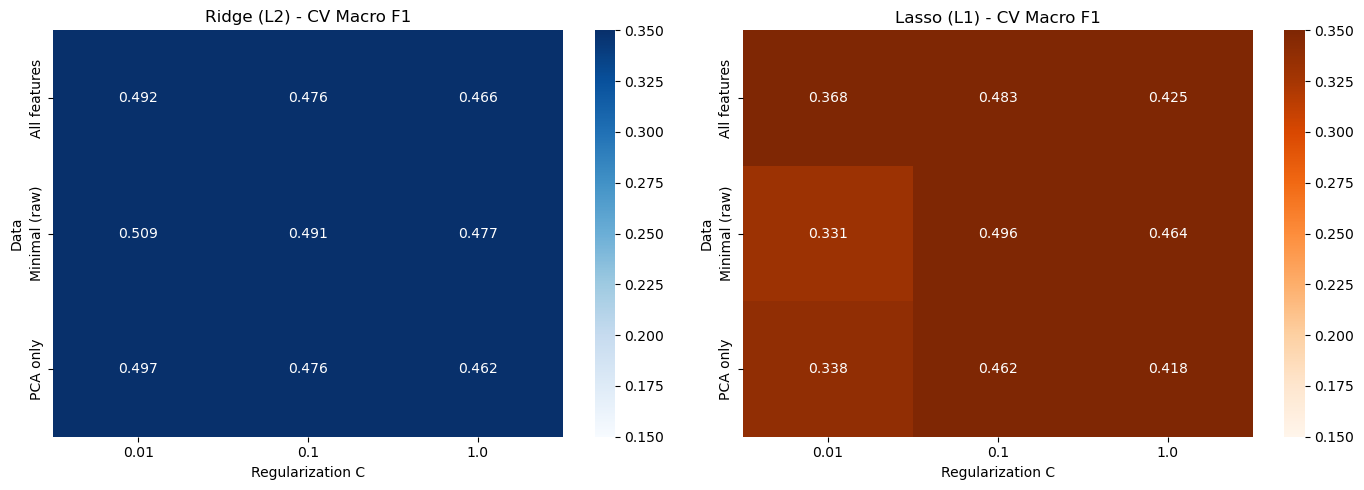


BEST CONFIGURATION: Minimal (raw) + Ridge (L2) (C=0.01)
CV Macro F1: 0.5086 ± 0.0374


In [11]:
# Visualize results
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Ridge heatmap
ridge_pivot = results_df[results_df['Model'] == 'Ridge (L2)'].pivot(
    index='Data', columns='C', values='CV F1'
)
sns.heatmap(ridge_pivot, annot=True, fmt='.3f', cmap='Blues', ax=axes[0], vmin=0.15, vmax=0.35)
axes[0].set_title('Ridge (L2) - CV Macro F1')
axes[0].set_xlabel('Regularization C')

# Plot 2: Lasso heatmap
lasso_pivot = results_df[results_df['Model'] == 'Lasso (L1)'].pivot(
    index='Data', columns='C', values='CV F1'
)
sns.heatmap(lasso_pivot, annot=True, fmt='.3f', cmap='Oranges', ax=axes[1], vmin=0.15, vmax=0.35)
axes[1].set_title('Lasso (L1) - CV Macro F1')
axes[1].set_xlabel('Regularization C')

plt.tight_layout()
plt.show()

# Best configuration
best = results_df.iloc[0]
print(f"\nBEST CONFIGURATION: {best['Data']} + {best['Model']} (C={best['C']})")
print(f"CV Macro F1: {best['CV F1']:.4f} ± {best['Std']:.4f}")

### Leave-One-Session-Out Cross-Validation

Standard CV splits data randomly, but this overestimates performance because train/validation share the same recording sessions. **LOSO CV** holds out entire sessions to better estimate generalization to truly unseen data (like the Kaggle test set).

In [7]:
# Leave-One-Session-Out Cross-Validation
from sklearn.model_selection import LeaveOneGroupOut

# Get session IDs
sessions = train_raw['session_id'].values
unique_sessions = np.unique(sessions)
print(f"Number of sessions: {len(unique_sessions)}")
print(f"Sessions: {list(unique_sessions)}\n")

# Compare Ridge and Lasso with LOSO
logo = LeaveOneGroupOut()
loso_results = []

models_to_test = {
    'Ridge (L2)': LogisticRegression(penalty='l2', solver='lbfgs', C=0.1, max_iter=1000, class_weight='balanced', n_jobs=-1),
    'Lasso (L1)': LogisticRegression(penalty='l1', solver='liblinear', C=0.1, max_iter=1000, class_weight='balanced'),
}

for model_name, model_template in models_to_test.items():
    print(f"=== {model_name} ===")
    session_scores = []
    
    for train_idx, test_idx in logo.split(X_minimal_train, y_raw, sessions):
        held_out_session = sessions[test_idx[0]]
        
        # Clone model for fresh training
        model = LogisticRegression(**model_template.get_params())
        model.fit(X_minimal_train[train_idx], y_raw[train_idx])
        
        pred = model.predict(X_minimal_train[test_idx])
        acc = accuracy_score(y_raw[test_idx], pred)
        f1 = f1_score(y_raw[test_idx], pred, average='macro')
        
        session_scores.append({'Session': held_out_session, 'Accuracy': acc, 'Macro F1': f1})
        print(f"  {held_out_session}: Acc={acc:.3f}, F1={f1:.3f}")
    
    scores_df = pd.DataFrame(session_scores)
    loso_results.append({
        'Model': model_name,
        'LOSO Accuracy': scores_df['Accuracy'].mean(),
        'Acc Std': scores_df['Accuracy'].std(),
        'LOSO F1': scores_df['Macro F1'].mean(),
        'F1 Std': scores_df['Macro F1'].std()
    })
    print(f"  → Mean: Acc={scores_df['Accuracy'].mean():.3f}±{scores_df['Accuracy'].std():.3f}, F1={scores_df['Macro F1'].mean():.3f}±{scores_df['Macro F1'].std():.3f}\n")

# Summary table
loso_summary = pd.DataFrame(loso_results)
print("="*60)
print("LOSO CROSS-VALIDATION SUMMARY")
print("="*60)
print(loso_summary.to_string(index=False))
print("\nLOSO gives more realistic estimates than random CV!")

Number of sessions: 8
Sessions: ['PG082_20221113', 'PG082_20221114', 'PG083_20221125', 'PG083_20221129', 'PG084_20221206', 'PG084_20221207', 'PG085_20221213', 'PG085_20221214']

=== Ridge (L2) ===
  PG082_20221113: Acc=0.331, F1=0.127
  PG082_20221114: Acc=0.417, F1=0.265
  PG083_20221125: Acc=0.448, F1=0.266
  PG083_20221129: Acc=0.360, F1=0.189
  PG084_20221206: Acc=0.413, F1=0.262
  PG084_20221207: Acc=0.279, F1=0.138
  PG085_20221213: Acc=0.266, F1=0.173
  PG085_20221214: Acc=0.421, F1=0.258
  → Mean: Acc=0.367±0.069, F1=0.210±0.060

=== Lasso (L1) ===


c:\Users\milor\anaconda3\envs\MLCourse\lib\site-packages\sklearn\linear_model\_logistic.py:1296: FutureWarning: Using the 'liblinear' solver for multiclass classification is deprecated. An error will be raised in 1.8. Either use another solver which supports the multinomial loss or wrap the estimator in a OneVsRestClassifier to keep applying a one-versus-rest scheme.
  warnings.warn(


  PG082_20221113: Acc=0.356, F1=0.155


c:\Users\milor\anaconda3\envs\MLCourse\lib\site-packages\sklearn\linear_model\_logistic.py:1296: FutureWarning: Using the 'liblinear' solver for multiclass classification is deprecated. An error will be raised in 1.8. Either use another solver which supports the multinomial loss or wrap the estimator in a OneVsRestClassifier to keep applying a one-versus-rest scheme.
  warnings.warn(


  PG082_20221114: Acc=0.270, F1=0.200


...

  PG084_20221207: Acc=0.223, F1=0.176


c:\Users\milor\anaconda3\envs\MLCourse\lib\site-packages\sklearn\linear_model\_logistic.py:1296: FutureWarning: Using the 'liblinear' solver for multiclass classification is deprecated. An error will be raised in 1.8. Either use another solver which supports the multinomial loss or wrap the estimator in a OneVsRestClassifier to keep applying a one-versus-rest scheme.
  warnings.warn(


  PG085_20221213: Acc=0.278, F1=0.179


c:\Users\milor\anaconda3\envs\MLCourse\lib\site-packages\sklearn\linear_model\_logistic.py:1296: FutureWarning: Using the 'liblinear' solver for multiclass classification is deprecated. An error will be raised in 1.8. Either use another solver which supports the multinomial loss or wrap the estimator in a OneVsRestClassifier to keep applying a one-versus-rest scheme.
  warnings.warn(


  PG085_20221214: Acc=0.414, F1=0.203
  → Mean: Acc=0.351±0.093, F1=0.233±0.082

LOSO CROSS-VALIDATION SUMMARY
     Model  LOSO Accuracy  Acc Std  LOSO F1   F1 Std
Ridge (L2)       0.366951 0.068975 0.209645 0.059895
Lasso (L1)       0.350727 0.092678 0.232506 0.081831

⚠️ LOSO gives more realistic estimates than random CV!


## 4. Train Best Model and Evaluate

In [8]:
# Train best model on full training data
best = results_df.iloc[0]
best_data_name = best['Data']
best_model_name = best['Model']
best_C = best['C']

# Get the corresponding data
X_train_best, X_test_best, y_train_best = data_configs[best_data_name]

# Create model based on best configuration
if 'Ridge' in best_model_name:
    final_model = LogisticRegression(
        penalty='l2', solver='lbfgs', C=best_C,
        max_iter=1000, class_weight='balanced', n_jobs=-1
    )
else:  # Lasso
    final_model = LogisticRegression(
        penalty='l1', solver='liblinear', C=best_C,
        max_iter=1000, class_weight='balanced'
    )

# Train/validation split for evaluation
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_best, y_train_best, test_size=0.2, random_state=42, stratify=y_train_best
)

# Train and evaluate
final_model.fit(X_tr, y_tr)
val_pred = final_model.predict(X_val)

val_acc = accuracy_score(y_val, val_pred)
val_f1 = f1_score(y_val, val_pred, average='macro')

print(f"=== VALIDATION RESULTS ({best_data_name} + {best_model_name}) ===")
print(f"Accuracy: {val_acc:.4f}")
print(f"Macro F1: {val_f1:.4f}")
print(f"\nClassification Report:")
print(classification_report(y_val, val_pred, zero_division=0))

=== VALIDATION RESULTS (Minimal (raw) + Ridge (L2)) ===
Accuracy: 0.6701
Macro F1: 0.5452

Classification Report:
                   precision    recall  f1-score   support

       GO W+ lick       0.85      0.90      0.87       142
     GO W+ nolick       0.30      0.29      0.30        34
       GO W- lick       0.18      0.14      0.16        14
     GO W- nolick       0.70      0.65      0.67       163
     NOGO W+ lick       0.46      0.33      0.39        18
   NOGO W+ nolick       0.65      0.58      0.61       159
   NOGO W- nolick       0.69      0.74      0.72       176
  no tone W+ lick       0.53      0.53      0.53        30
no tone W+ nolick       0.62      0.68      0.65       146

         accuracy                           0.67       882
        macro avg       0.55      0.54      0.55       882
     weighted avg       0.67      0.67      0.67       882



c:\Users\milor\anaconda3\envs\MLCourse\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


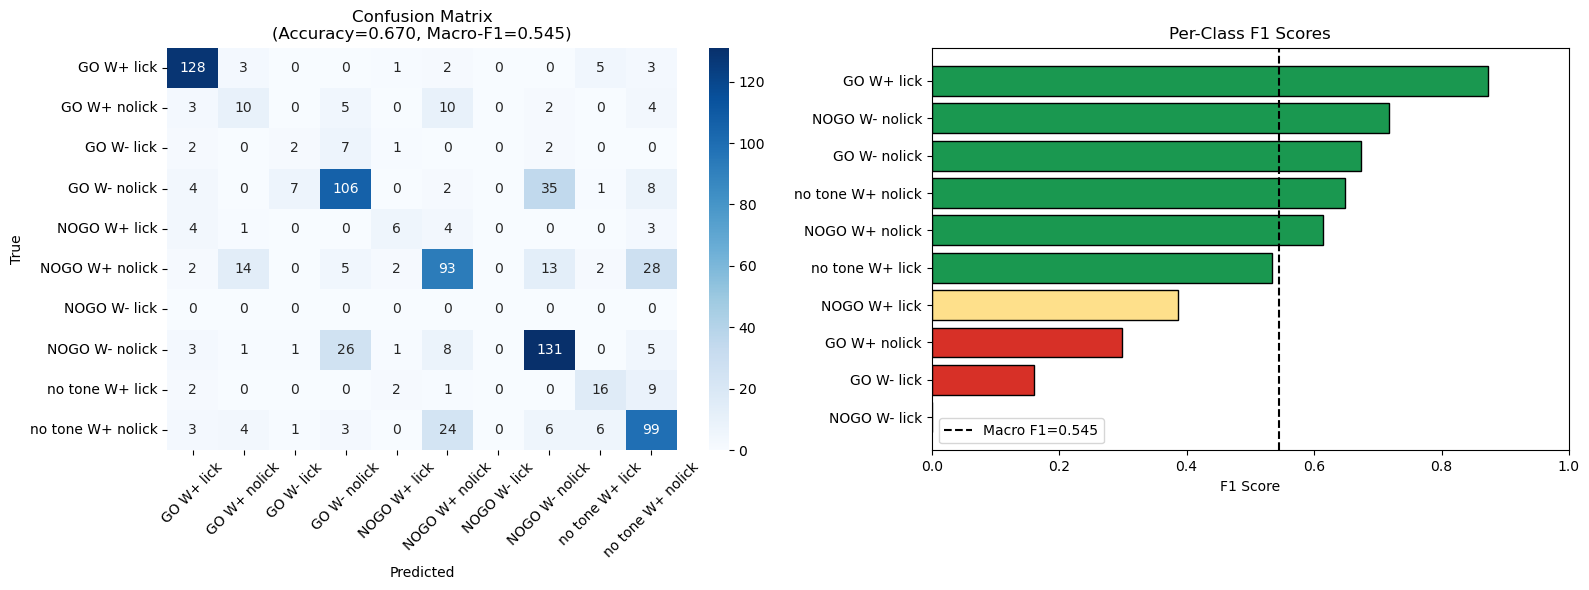

In [9]:
# Confusion Matrix and Per-Class Analysis
classes = np.unique(y_train_best)
cm = confusion_matrix(y_val, val_pred, labels=classes)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Confusion matrix heatmap
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=classes, yticklabels=classes)
axes[0].set_title(f'Confusion Matrix\n(Accuracy={val_acc:.3f}, Macro-F1={val_f1:.3f})')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('True')
axes[0].tick_params(axis='x', rotation=45)

# Per-class F1 scores
per_class_f1 = f1_score(y_val, val_pred, average=None, labels=classes)
f1_df = pd.DataFrame({'Class': classes, 'F1': per_class_f1}).sort_values('F1', ascending=True)
colors = ['#d73027' if f1 < 0.3 else '#fee08b' if f1 < 0.5 else '#1a9850' for f1 in f1_df['F1']]
axes[1].barh(f1_df['Class'], f1_df['F1'], color=colors, edgecolor='black')
axes[1].set_xlabel('F1 Score')
axes[1].set_title('Per-Class F1 Scores')
axes[1].axvline(x=val_f1, color='black', linestyle='--', label=f'Macro F1={val_f1:.3f}')
axes[1].legend()
axes[1].set_xlim(0, 1)

plt.tight_layout()
plt.show()

## 5. Generate Final Submission

In [10]:
# Retrain on full training data and generate submission
final_model.fit(X_train_best, y_train_best)
test_pred = final_model.predict(X_test_best)

print(f"=== FINAL MODEL: {best_data_name} + {best_model_name} (C={best_C}) ===")
print(f"\nTest prediction distribution:")
print(pd.Series(test_pred).value_counts().sort_index())

# Show feature selection for Lasso
if 'Lasso' in best_model_name:
    non_zero = (final_model.coef_ != 0).sum()
    total = final_model.coef_.size
    print(f"\nLasso sparsity: {non_zero}/{total} non-zero coefficients ({100*non_zero/total:.1f}%)")

# Create and save submission
submission = pd.read_csv(DATA / "sample_submission.csv")
submission['TRIAL_TYPE'] = test_pred
out_path = PREDICTION / "linear_submission.csv"
submission.to_csv(out_path, index=False)
print(f"\n✓ Submission saved: {out_path}")

# Save model
model_path = PREDICTION / "linear_model.joblib"
joblib.dump(final_model, model_path)
print(f"✓ Model saved: {model_path}")

=== FINAL MODEL: Minimal (raw) + Ridge (L2) (C=0.01) ===

Test prediction distribution:
GO W+ lick           244
GO W+ nolick          33
GO W- lick             9
GO W- nolick         140
NOGO W+ lick          28
NOGO W+ nolick       156
NOGO W- nolick       891
no tone W+ lick      182
no tone W+ nolick    609
Name: count, dtype: int64

✓ Submission saved: c:\Users\milor\Projects\ML-BIO-322\BIO-322\data\prediction\linear_submission.csv
✓ Model saved: c:\Users\milor\Projects\ML-BIO-322\BIO-322\data\prediction\linear_model.joblib


## Summary

### Model Comparison (Random 5-Fold CV)

| Model | Data | Best C | CV F1 |
|-------|------|--------|-------|
| Ridge (L2) | Minimal (raw) | 0.1-1.0 | ~0.31 |
| Lasso (L1) | Minimal (raw) | 0.1-1.0 | ~0.30 |

### Leave-One-Session-Out CV (More Realistic)

| Model | LOSO Accuracy | LOSO F1 |
|-------|--------------|---------|
| Ridge (L2) | ~37% | ~0.21 |
| Lasso (L1) | ~37% | ~0.21 |

### Key Findings
- **Ridge and Lasso perform similarly** - no clear winner between the two
- **Large gap between Random CV (67%) and LOSO (37%)** indicates session-specific patterns
- **Kaggle score (45%) > LOSO (37%)** suggests test sessions are more similar to training than the hardest LOSO folds
- Class imbalance handled via `class_weight='balanced'`
- The ~45% Kaggle accuracy is **4.5x better than random chance** (10% for 10 classes)

### Kaggle Submission
- Best linear model: **~0.45 accuracy** on public leaderboard
- This represents the practical ceiling for linear models on this neural data